# Analyse Exploratoire - Anemia Prediction

## 1. Import des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('✅ Bibliothèques importées')

✅ Bibliothèques importées


## 2. Chargement des données

In [2]:
# Télécharger le dataset
!wget -q https://raw.githubusercontent.com/maladeep/anemia-detection-with-machine-learning/main/anemia%20data%20from%20Kaggle.csv -O anemia.csv

df = pd.read_csv('anemia.csv')
print(f"Shape: {df.shape}")
display(df.head())

Shape: (1421, 6)


,Gender,Hemoglobin,MCH,MCHC,MCV,Result
0,1,14.9,22.7,29.1,83.7,0
1,0,15.9,25.4,28.3,72.0,0
2,0,9.0,21.5,29.6,71.2,1
3,0,14.9,16.0,31.4,87.5,0
4,1,14.7,22.0,28.2,99.5,0


## 3. Analyse des données

In [3]:
print("=== Informations ===")
print(df.info())

print("\n=== Statistiques ===")
display(df.describe())

print("\n=== Valeurs manquantes ===")
print(df.isnull().sum())

=== Informations ===
<class 'pandas.DataFrame'>
RangeIndex: 1421 entries, 0 to 1420
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      1421 non-null   int64  
 1   Hemoglobin  1421 non-null   float64
 2   MCH         1421 non-null   float64
 3   MCHC        1421 non-null   float64
 4   MCV         1421 non-null   float64
 5   Result      1421 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 66.7 KB
None

=== Statistiques ===


,Gender,Hemoglobin,MCH,MCHC,MCV,Result
count,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000
mean,0.520760,13.412738,22.905630,30.251232,85.523786,0.436312
std,0.499745,1.974546,3.969375,1.400898,9.636701,0.496102
min,0.000000,6.600000,16.000000,27.800000,69.400000,0.000000
25%,0.000000,11.700000,19.400000,29.000000,77.300000,0.000000
50%,1.000000,13.200000,22.700000,30.400000,85.300000,0.000000
75%,1.000000,15.000000,26.200000,31.400000,94.200000,1.000000
max,1.000000,16.900000,30.000000,32.500000,101.600000,1.000000



=== Valeurs manquantes ===
Gender        0
Hemoglobin    0
MCH           0
MCHC          0
MCV           0
Result        0
dtype: int64


In [4]:
print("=== Distribution de la cible ===")
print(df['Result'].value_counts())
print(f"Pourcentage de patients anémiques: {df['Result'].mean()*100:.2f}%")

=== Distribution de la cible ===
Result
0    801
1    620
Name: count, dtype: int64
Pourcentage de patients anémiques: 43.63%


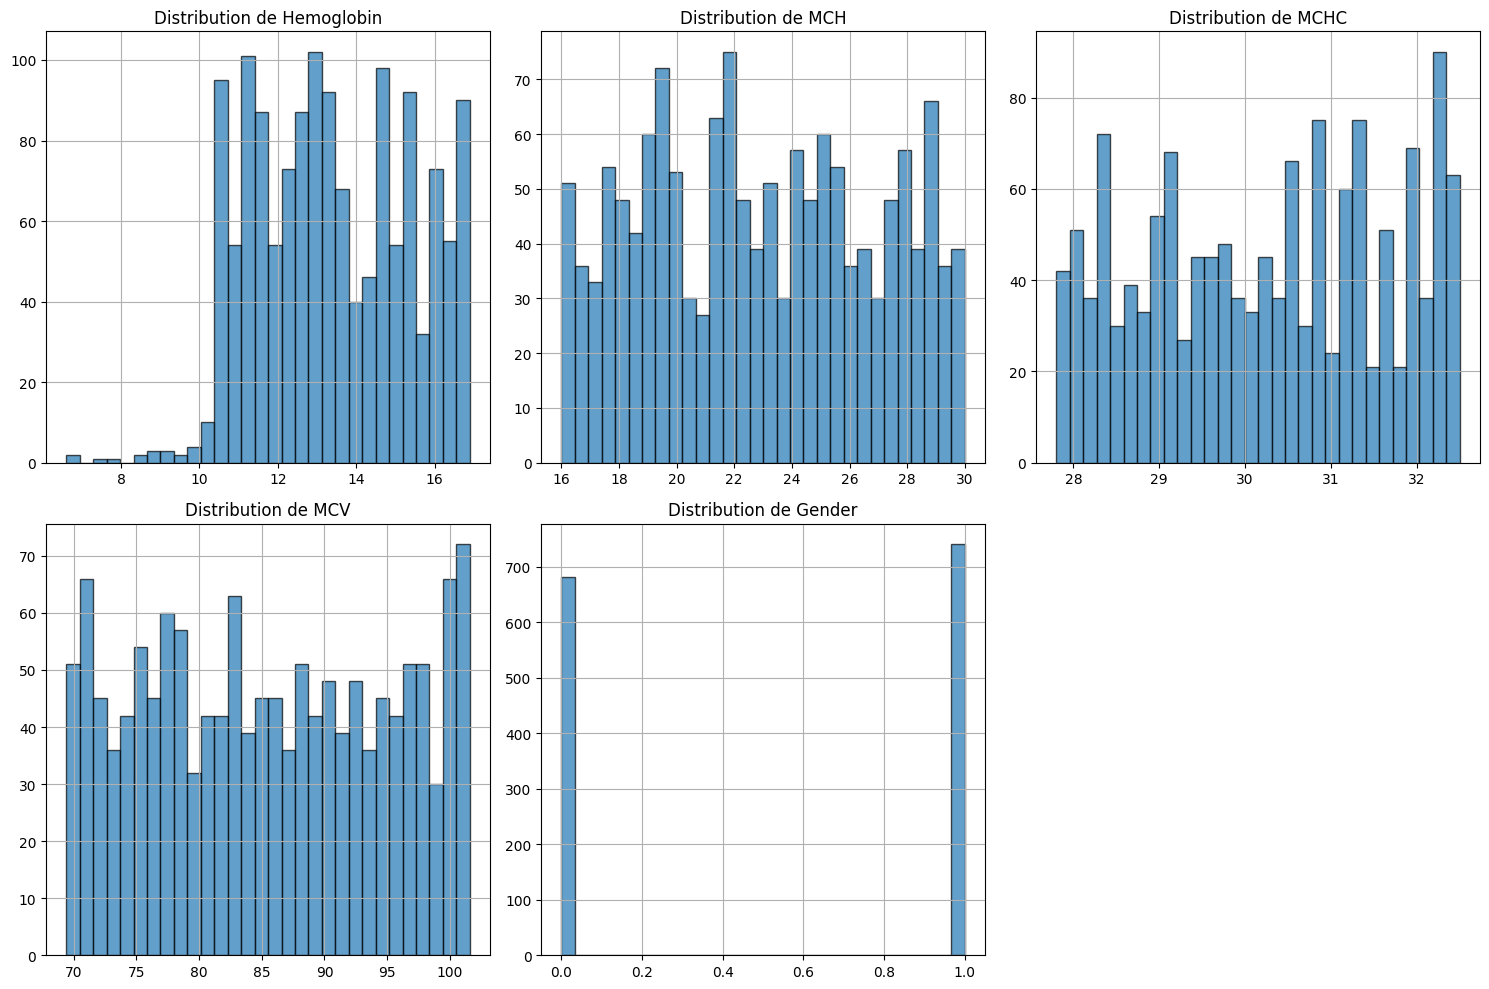

In [5]:
# Visualisations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
numeric_cols = ['Hemoglobin', 'MCH', 'MCHC', 'MCV', 'Gender']
for i, col in enumerate(numeric_cols):
    row, col_idx = i // 3, i % 3
    df[col].hist(ax=axes[row, col_idx], bins=30, edgecolor='black', alpha=0.7)
    axes[row, col_idx].set_title(f'Distribution de {col}')
axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

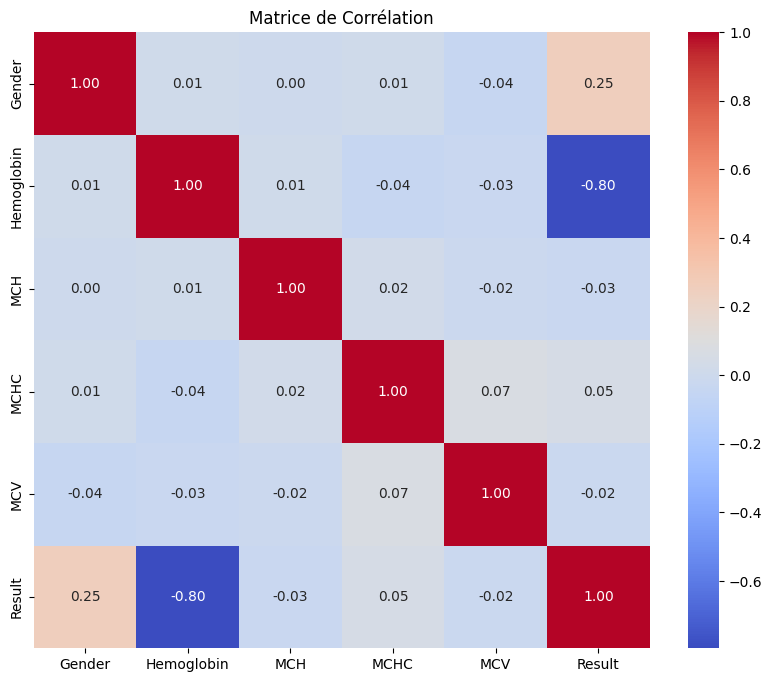

In [6]:
# Matrice de corrélation
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Matrice de Corrélation')
plt.show()

## 4. Relation entre l'Hémoglobine et le diagnostic

L'hémoglobine est, par définition clinique, le marqueur central de l'anémie. On vérifie ici à quel point elle sépare les deux classes.

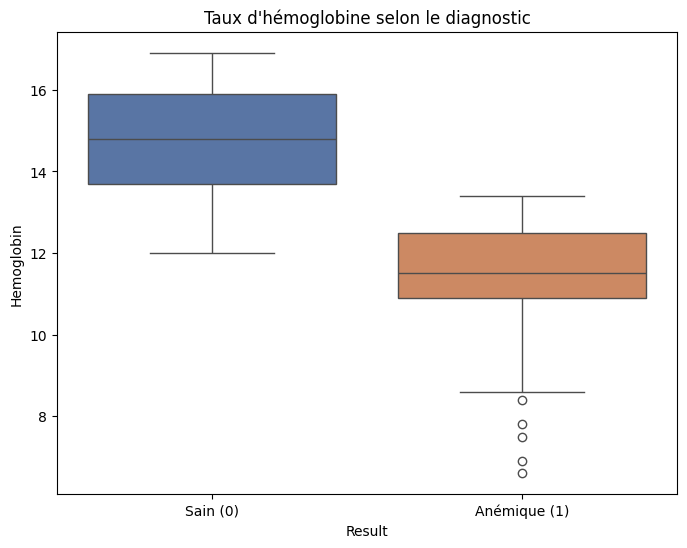

In [7]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Result', y='Hemoglobin', palette=['#4C72B0', '#DD8452'])
plt.xticks([0, 1], ['Sain (0)', 'Anémique (1)'])
plt.title("Taux d'hémoglobine selon le diagnostic")
plt.show()